# Assignment 4 - Simple Neural Networks (**PyTorch Version**)

Build a fraud classifier from transaction data.


## What stays the same from the original assignment

- **Task:** predict fraud from transaction data.
- **Deliverables:** one training notebook and one prediction notebook.
- **Grading:**
  - Code produces predictions — **40**
  - Accuracy — **30**
  - Explanation — **20**
  - Balance / variable transformations — **10**








In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

import joblib
from pathlib import Path

# Device setup in the same spirit as the reference notebook
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cpu


## Load Data

Expected training file: `fraudTrain.csv`


In [21]:
df = pd.read_csv("fraudTrain.csv.zip")
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.shape)
df.head()

(1296675, 22)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [22]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
trans_date_trans_time,1296675,1274791,2019-04-22 16:02:01,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cc_num,1296675.0,NaN,NaN,NaN,417192042079726656.0,1308806447000789248.0,60416207185.0,180042946491150.0,3521417320836166.0,4642255475285942.0,4992346398065154048.0
merchant,1296675,693,fraud_Kilback LLC,4403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1296675,14,gas_transport,131659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amt,1296675.0,NaN,NaN,NaN,70.351035,160.316039,1.0,9.65,47.52,83.14,28948.9
first,1296675,352,Christopher,26669,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last,1296675,481,Smith,28794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1296675,2,F,709863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street,1296675,983,864 Reynolds Plains,3123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,1296675,894,Birmingham,5617,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Deal with Lat/Lon

A plain latitude/longitude pair is not usually ideal for a tabular neural network.
A more useful transformation is to create a **distance-like feature** between the customer and merchant.

**TODO:** create at least one useful location feature.
Suggested idea: distance between `(lat, long)` and `(merch_lat, merch_long)`.


In [4]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

df["distance_km"] = haversine_km(df["lat"], df["long"], df["merch_lat"], df["merch_long"])

### Deal with Time

The original prompt suggests that time and DOB are not especially useful in raw form, but can become useful after transformation.

**TODO:** create time-based features such as:
- hour of day
- day of week
- month
- customer age
- cyclical encoding of hour


In [5]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])
df["hour"] = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
df["month"] = df["trans_date_trans_time"].dt.month
df["customer_age"] = ((df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25).astype(float)
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

### Check Target Balance

This dataset is imbalanced, so you should inspect the fraud rate before training.


In [6]:
df["is_fraud"].value_counts(normalize=True)

,proportion
is_fraud,
0,0.994211
1,0.005789


### Prepare Data

Recommended workflow:
1. Choose features.
2. Separate numeric and categorical columns.
3. One-hot encode categorical variables.
4. Standardize numeric variables.
5. Combine everything into a single feature matrix.

You should also decide which columns to drop because they are IDs, raw timestamps, or leakage-prone text fields.


In [7]:
TARGET = "is_fraud"

engineered_numeric = [
    "amt", "city_pop", "distance_km", "customer_age",
    "hour_sin", "hour_cos", "day_of_week", "month"
]
categorical_cols = ["category", "gender"]

drop_cols = [
    TARGET,
    "trans_date_trans_time", "dob",
    "first", "last", "street", "city", "state", "job",
    "trans_num", "merchant", "cc_num",
    "lat", "long", "merch_lat", "merch_long",
    "unix_time", "zip", "hour" # 'hour' is dropped since we have 'hour_sin' and 'hour_cos'
]

# Separate features (X) and target (y)
X = df.drop(columns=drop_cols)
y = df[TARGET]

# Identify numerical and categorical features from the remaining columns
numeric_cols = [col for col in engineered_numeric if col in X.columns]
categorical_cols = [col for col in categorical_cols if col in X.columns]

# Initialize preprocessors
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
scaler = StandardScaler()

# Apply One-Hot Encoding to categorical columns
X_cat_encoded = onehot_encoder.fit_transform(X[categorical_cols])
X_cat_encoded_df = pd.DataFrame(X_cat_encoded, columns=onehot_encoder.get_feature_names_out(categorical_cols), index=X.index)

# Apply Standardization to numerical columns
X_num_scaled = scaler.fit_transform(X[numeric_cols])
X_num_scaled_df = pd.DataFrame(X_num_scaled, columns=numeric_cols, index=X.index)

# Combine preprocessed features
X_processed = pd.concat([X_num_scaled_df, X_cat_encoded_df], axis=1)

print(f"Shape of X_processed: {X_processed.shape}")
print(f"Shape of y: {y.shape}")
X_processed.head()

Shape of X_processed: (1296675, 24)
Shape of y: (1296675,)


,amt,city_pop,distance_km,customer_age,hour_sin,hour_cos,day_of_week,month,category_entertainment,category_food_dining,...,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_F,gender_M
0,-0.407826,-0.282589,0.085274,-0.872823,0.197179,1.43329,-0.941975,-1.504564,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.230039,-0.293670,-1.576488,-0.314203,0.197179,1.43329,-0.941975,-1.504564,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.934149,-0.280406,1.102157,0.629736,0.197179,1.43329,-0.941975,-1.504564,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.158132,-0.287742,0.671726,0.343422,0.197179,1.43329,-0.941975,-1.504564,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.177094,-0.293835,0.049528,-0.760752,0.197179,1.43329,-0.941975,-1.504564,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


### Split Data

Use a stratified split so the fraud rate stays similar in train/validation/test.


In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(X_processed, y, stratify=y, test_size=0.30, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, stratify=y_temp, test_size=0.50, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_valid shape: {X_valid.shape}, y_valid shape: {y_valid.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (907672, 24), y_train shape: (907672,)
X_valid shape: (194501, 24), y_valid shape: (194501,)
X_test shape: (194502, 24), y_test shape: (194502,)


### Convert to Tensors and DataLoaders

Follow the reference notebook style:
- convert arrays to tensors
- wrap them in `TensorDataset`
- use `DataLoader`
- handle imbalance with either:
  - `WeightedRandomSampler`, or
  - `pos_weight` in `BCEWithLogitsLoss`


In [9]:
# Convert arrays to tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
X_valid_tensor = torch.tensor(X_valid.values, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid.values.reshape(-1, 1), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32)

# Wrap them in TensorDataset
train_ds = TensorDataset(X_train_tensor, y_train_tensor)
valid_ds = TensorDataset(X_valid_tensor, y_valid_tensor)
test_ds = TensorDataset(X_test_tensor, y_test_tensor)

# Handle imbalance with WeightedRandomSampler for training data
class_counts = y_train.value_counts()
num_samples = sum(class_counts)
labels = y_train.values

class_weights = {0: num_samples / class_counts[0], 1: num_samples / class_counts[1]}
sample_weights = np.array([class_weights[label] for label in labels])
sample_weights = torch.from_numpy(sample_weights)

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# Use DataLoader
batch_size = 1024 # You can adjust this
train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False) # No need to shuffle validation/test
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(valid_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 887
Number of validation batches: 190
Number of test batches: 190


### Model

Build a small multilayer perceptron (MLP) for binary classification.

Suggested starting point:
- Linear → ReLU → Dropout
- Linear → ReLU → Dropout
- Linear → 1 output logit


In [11]:
# TODO: define your PyTorch model

class FraudMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

### Train the Model

Use:
- `BCEWithLogitsLoss`
- `Adam`
- an epoch loop with training and validation loss

You should move both the model and each batch to `device`.


In [12]:
input_dim = X_train_tensor.shape[1]
model = FraudMLP(input_dim).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

train_losses = []
valid_losses = []
valid_roc_auc_scores = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    valid_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            valid_loss += loss.item() * inputs.size(0)

            probs = torch.sigmoid(outputs)
            all_preds.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_valid_loss = valid_loss / len(valid_loader.dataset)
    valid_losses.append(epoch_valid_loss)

    # Calculate ROC-AUC
    roc_auc = roc_auc_score(all_labels, all_preds)
    valid_roc_auc_scores.append(roc_auc)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss: {epoch_train_loss:.4f}, "
          f"Valid Loss: {epoch_valid_loss:.4f}, "
          f"Valid ROC-AUC: {roc_auc:.4f}")

Epoch 1/10: Train Loss: 0.1951, Valid Loss: 0.0953, Valid ROC-AUC: 0.9939
Epoch 2/10: Train Loss: 0.0898, Valid Loss: 0.0641, Valid ROC-AUC: 0.9967
Epoch 3/10: Train Loss: 0.0690, Valid Loss: 0.0569, Valid ROC-AUC: 0.9975
Epoch 4/10: Train Loss: 0.0596, Valid Loss: 0.0572, Valid ROC-AUC: 0.9977
Epoch 5/10: Train Loss: 0.0543, Valid Loss: 0.0537, Valid ROC-AUC: 0.9977
Epoch 6/10: Train Loss: 0.0504, Valid Loss: 0.0459, Valid ROC-AUC: 0.9978
Epoch 7/10: Train Loss: 0.0471, Valid Loss: 0.0488, Valid ROC-AUC: 0.9979
Epoch 8/10: Train Loss: 0.0445, Valid Loss: 0.0478, Valid ROC-AUC: 0.9979
Epoch 9/10: Train Loss: 0.0421, Valid Loss: 0.0469, Valid ROC-AUC: 0.9978
Epoch 10/10: Train Loss: 0.0410, Valid Loss: 0.0402, Valid ROC-AUC: 0.9978


### Analyze Misclassified Cases

Test ROC-AUC: 0.9978

Classification Report on Test Data:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99    193376
         1.0       0.26      0.97      0.41      1126

    accuracy                           0.98    194502
   macro avg       0.63      0.98      0.70    194502
weighted avg       1.00      0.98      0.99    194502


Confusion Matrix on Test Data:


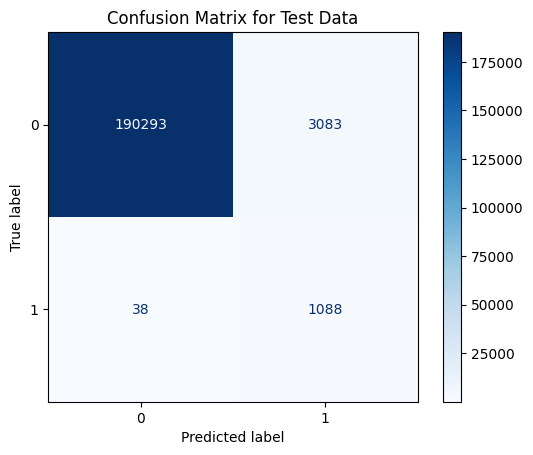

In [13]:
# Evaluate on test data
model.eval()
all_preds_test = []
all_labels_test = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs)
        all_preds_test.extend(probs.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

# Convert to numpy arrays
all_preds_test = np.array(all_preds_test)
all_labels_test = np.array(all_labels_test)

# Calculate ROC-AUC
roc_auc_test = roc_auc_score(all_labels_test, all_preds_test)
print(f"Test ROC-AUC: {roc_auc_test:.4f}")

# You can also tune the classification threshold. For simplicity, we'll use 0.5 here.
# For a more robust solution, you might want to find the optimal threshold
# based on PR curve or specific business requirements.
threshold = 0.5
y_pred_test = (all_preds_test > threshold).astype(int)

# Classification Report
print("\nClassification Report on Test Data:")
print(classification_report(all_labels_test, y_pred_test))

# Confusion Matrix
print("\nConfusion Matrix on Test Data:")
cm = confusion_matrix(all_labels_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Test Data")
plt.show()

In [14]:
# Ensure y_pred_test is a flat array for boolean indexing
y_pred_test_flat = y_pred_test.flatten()
y_test_flat = y_test.values.flatten()

# Identify False Positives (Actual 0, Predicted 1)
fp_indices = X_test.index[(y_test_flat == 0) & (y_pred_test_flat == 1)]
false_positives = df.loc[fp_indices]

print(f"Number of False Positives: {len(false_positives)}")
print("Sample of False Positives (Actual Non-Fraud, Predicted Fraud):")
display(false_positives.head())


Number of False Positives: 3083
Sample of False Positives (Actual Non-Fraud, Predicted Fraud):


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,merch_lat,merch_long,is_fraud,distance_km,hour,day_of_week,month,customer_age,hour_sin,hour_cos
239839,2019-04-29 23:44:20,6544734391390261,fraud_Crooks and Sons,personal_care,25.05,John,Myers,M,701 Wilson Divide,Highland,...,41.684298,-86.913257,0,47.595868,23,0,4,37.218344,-0.258819,0.965926
262766,2019-05-11 03:14:13,3566373869538620,"fraud_Rippin, Kub and Mann",misc_net,782.37,Steven,Castaneda,M,46809 Toni Flat Suite 216,Lamy,...,34.697732,-106.560992,0,99.171009,3,5,5,54.882957,0.707107,0.707107
568507,2019-08-30 04:49:47,3541160328600277,fraud_Roob LLC,grocery_net,12.78,Jason,Singh,M,4720 Anna Ways,Murrayville,...,40.485569,-91.059130,0,123.294120,4,4,8,16.314853,0.866025,0.500000
276314,2019-05-16 23:25:27,3583793405872580,fraud_Simonis-Prohaska,misc_pos,9.16,Beth,Lambert,F,6447 Johnson Estates Apt. 986,Roosevelt,...,34.544355,-98.216568,0,77.780937,23,3,5,48.632444,-0.258819,0.965926
654180,2019-10-05 23:03:48,3533012926413100,fraud_Erdman-Schaden,personal_care,15.89,Megan,Bernard,F,128 Nathan Ramp,Barneveld,...,43.154391,-75.273505,0,11.928638,23,5,10,25.596167,-0.258819,0.965926


In [15]:
# Identify False Negatives (Actual 1, Predicted 0)
fn_indices = X_test.index[(y_test_flat == 1) & (y_pred_test_flat == 0)]
false_negatives = df.loc[fn_indices]

print(f"Number of False Negatives: {len(false_negatives)}")
print("Sample of False Negatives (Actual Fraud, Predicted Non-Fraud):")
display(false_negatives.head())


Number of False Negatives: 38
Sample of False Negatives (Actual Fraud, Predicted Non-Fraud):


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,merch_lat,merch_long,is_fraud,distance_km,hour,day_of_week,month,customer_age,hour_sin,hour_cos
1262034,2020-06-08 19:48:27,4334230547694630,fraud_Connelly PLC,food_dining,109.87,Scott,Martin,M,7483 Navarro Flats,Freedom,...,43.766999,-111.557074,1,93.650392,19,0,6,52.851472,-0.965926,0.258819
1211858,2020-05-21 22:35:22,3567697931646329,fraud_Schimmel-Olson,kids_pets,16.38,John,Stevens,M,428 Morgan River,Hudson,...,42.415671,-74.233956,1,43.595398,22,3,5,21.812457,-0.500000,0.866025
115808,2019-03-06 17:47:20,4998109455173950,fraud_Wilkinson PLC,kids_pets,19.58,Mary,Pruitt,F,2819 Luke Greens Suite 563,Kansas City,...,39.281459,-95.272647,1,68.331776,17,2,3,31.296372,-0.965926,-0.258819
283718,2019-05-19 22:32:55,2720433095629877,fraud_Ullrich Ltd,kids_pets,17.33,Mark,Wood,M,854 Walker Dale Suite 488,Bowdoin,...,43.309343,-70.700479,1,102.042222,22,6,5,21.738535,-0.500000,0.866025
657411,2019-10-06 23:27:15,3540862542587229,fraud_Wilkinson LLC,personal_care,50.87,Nancy,Roach,F,376 Brown Courts,Yellowstone National Park,...,44.220609,-111.080149,1,73.874005,23,6,10,77.886379,-0.258819,0.965926


### Descriptive Statistics for Misclassified Cases

Let's look at some key features for these misclassified transactions.

In [16]:
print("False Positives - Amount Distribution:")
display(false_positives['amt'].describe())

print("False Negatives - Amount Distribution:")
display(false_negatives['amt'].describe())


False Positives - Amount Distribution:


,amt
count,3083.000000
mean,180.471794
std,324.047800
min,1.010000
25%,13.325000
50%,21.450000
75%,126.470000
max,1529.900000


False Negatives - Amount Distribution:


,amt
count,38.000000
mean,65.682105
std,111.300319
min,6.330000
25%,17.475000
50%,20.870000
75%,50.530000
max,606.650000


In [17]:
print("False Positives - Category Distribution:")
display(false_positives['category'].value_counts(normalize=True).head())

print("False Negatives - Category Distribution:")
display(false_negatives['category'].value_counts(normalize=True).head())


False Positives - Category Distribution:


,proportion
category,
personal_care,0.187155
kids_pets,0.170937
travel,0.107363
food_dining,0.094713
misc_pos,0.094064


False Negatives - Category Distribution:


,proportion
category,
personal_care,0.263158
kids_pets,0.236842
food_dining,0.131579
misc_pos,0.131579
health_fitness,0.105263


In [18]:
print("False Positives - Distance (km) Distribution:")
display(false_positives['distance_km'].describe())

print("False Negatives - Distance (km) Distribution:")
display(false_negatives['distance_km'].describe())


False Positives - Distance (km) Distribution:


,distance_km
count,3083.000000
mean,78.621929
std,27.318925
min,2.688377
25%,60.738739
50%,80.712338
75%,98.955325
max,141.270085


False Negatives - Distance (km) Distribution:


,distance_km
count,38.000000
mean,82.279856
std,27.851463
min,26.919877
25%,63.731564
50%,87.552471
75%,102.109444
max,138.213758


### Evaluate

At minimum, produce:
- confusion matrix
- classification report
- ROC-AUC if possible

You may also tune the classification threshold rather than always using 0.50.


### Save What the Prediction Notebook Needs

Your prediction notebook should be able to `Run all` without retraining.
So save:
- the trained model weights
- the scaler
- the encoder
- the list of feature columns / metadata needed for preprocessing


In [19]:
# Save artifacts
torch.save(model.state_dict(), "fraud_mlp_state_dict.pt")
joblib.dump(scaler, "fraud_scaler.joblib")
joblib.dump(onehot_encoder, "fraud_encoder.joblib")

# Also save feature names in the correct order for consistent preprocessing
feature_columns = X_processed.columns.tolist()
joblib.dump(feature_columns, "feature_columns.joblib")

print("Model state dictionary, scaler, encoder, and feature columns saved.")

Model state dictionary, scaler, encoder, and feature columns saved.


## Short Explanation (write your own)

In your final submission, include a short explanation covering:
- imbalance handling
- treatment of location and time variables
- model structure
- optimization choices such as dropout, regularization, thresholding, or feature selection



This project builds a neural network that learns to detect fraudulent transactions.

**1. Handling Imbalanced Data**
In real-world fraud data, genuine transactions far outnumber fraudulent ones. If left unchecked, the model would just predict "not fraud" every time and still look accurate. To fix this, fraudulent transactions were shown to the model more often during training using a technique called WeightedRandomSampler, so the model gets enough exposure to both types.

**2. Making Location and Time Useful**
Raw coordinates and timestamps aren't very useful on their own, so they were transformed:
- **Location:** Instead of using raw latitude/longitude, the straight-line distance (in km) between the customer and the merchant was calculated. A transaction happening far from home is a red flag.
- **Time:** The date and time were broken down into hour, day of the week, and month. The customer's age was also calculated from their date of birth. Since time is cyclical (e.g., 11 PM and 12 AM are close), the hour was converted into sine and cosine values so the model understands that pattern naturally.

**3. Model Design**
A simple neural network (MLP) was used with the following structure:
- Takes in the input features → passes through 128 neurons → ReLU activation
- Randomly drops 20% of neurons (Dropout) to avoid over-memorizing
- Passes through 64 neurons → ReLU activation
- Another 20% Dropout
- Final single output neuron that decides: fraud or not fraud

**4. Training Choices**
- **Loss Function:** BCEWithLogitsLoss was used — it's a stable and reliable way to train binary (yes/no) classifiers.
- **Optimizer:** Adam was used to update the model's weights. It's efficient and works well in most situations, with a learning rate of 0.001.
- **Dropout:** Used to prevent the model from overfitting (memorizing training data instead of learning general patterns).
- **Feature Cleanup:** Columns that were irrelevant or could cause data leakage (like raw IDs or original timestamps) were removed to keep the model clean and focused.

-The data was split into 70% training, 15% validation, and 15% test sets using stratified splitting to preserve the fraud ratio across all splits.

-A classification threshold of 0.5 was used. This results in high recall (0.97) — catching almost all fraud — but lower precision (0.26), meaning some legitimate transactions are flagged. The threshold can be tuned higher to reduce false alarms depending on business needs.

-Columns like cc_num, trans_num, and merchant were dropped as they are unique IDs or high-cardinality text fields. Raw lat, long, merch_lat, merch_long were dropped after engineering distance_km. The raw hour was dropped after creating hour_sin and hour_cos.

-The model achieved a test ROC-AUC of 0.9978, indicating very strong ability to distinguish fraudulent from legitimate transactions.